In [9]:
import pandas as pd

benin = pd.read_csv('eda/data/eda_clean.csv')
sierra_leone = pd.read_csv('sierraleone/data/sierraleone_clean.csv')
togo = pd.read_csv('togo/data/togo_clean.csv')

# Add a country label to each
benin['Country'] = 'Benin'
sierra_leone['Country'] = 'Sierra Leone'
togo['Country'] = 'Togo'

# Combine into one DataFrame
df_all = pd.concat([benin, sierra_leone, togo], ignore_index=True)


C:\Users\foziya fetudin\AppData\Local\Temp\ipykernel_2396\1942134488.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Country', y=metric, data=df_all, palette='Set2')


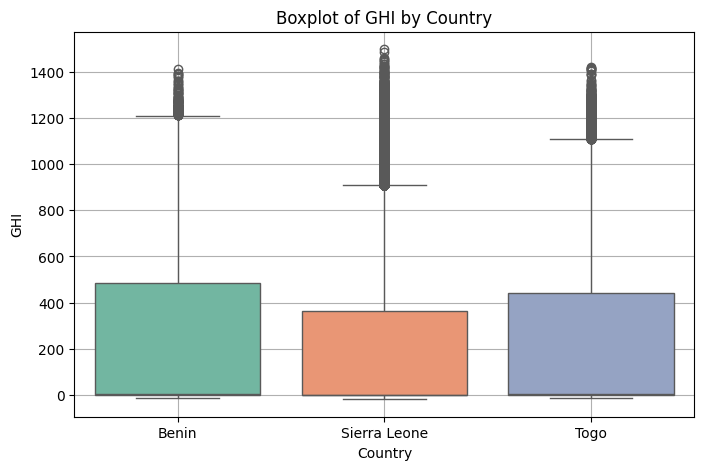

C:\Users\foziya fetudin\AppData\Local\Temp\ipykernel_2396\1942134488.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Country', y=metric, data=df_all, palette='Set2')


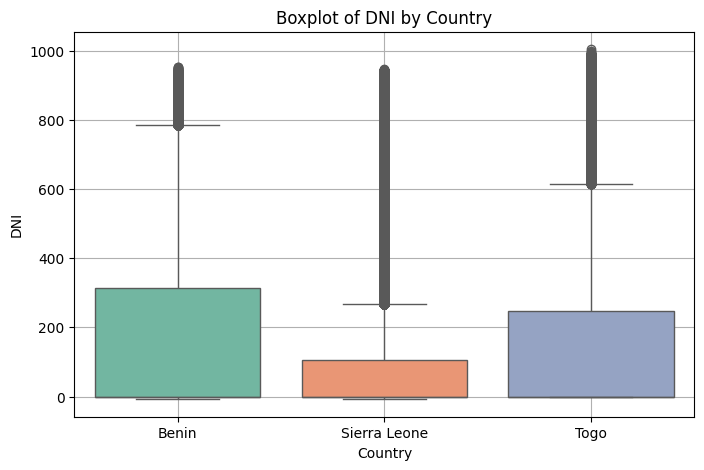

C:\Users\foziya fetudin\AppData\Local\Temp\ipykernel_2396\1942134488.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Country', y=metric, data=df_all, palette='Set2')


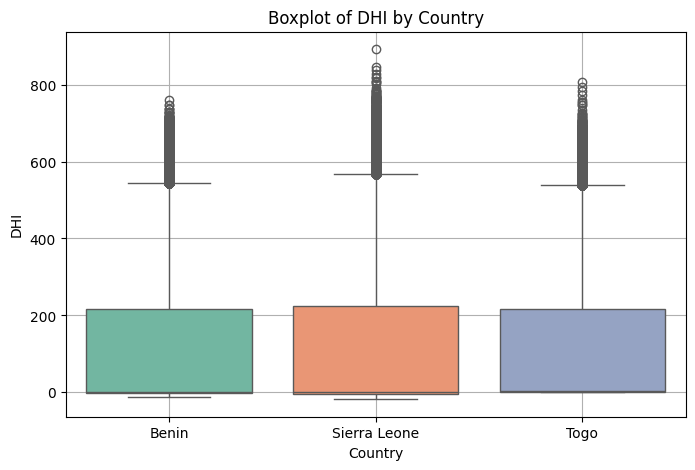

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

for metric in ['GHI', 'DNI', 'DHI']:
    plt.figure(figsize=(8, 5))
    sns.boxplot(x='Country', y=metric, data=df_all, palette='Set2')
    plt.title(f'Boxplot of {metric} by Country')
    plt.grid(True)
    plt.show()


In [11]:
summary = df_all.groupby('Country')[['GHI', 'DNI', 'DHI']].agg(['mean', 'median', 'std']).round(2)
summary.columns = ['_'.join(col) for col in summary.columns]
summary


,GHI_mean,GHI_median,GHI_std,DNI_mean,DNI_median,DNI_std,DHI_mean,DHI_median,DHI_std
Country,,,,,,,,,
Benin,240.56,1.8,331.13,167.19,-0.1,261.71,115.36,1.6,158.69
Sierra Leone,201.96,0.3,298.50,116.38,-0.1,218.65,113.72,-0.1,158.95
Togo,230.56,2.1,322.53,151.26,0.0,250.96,116.44,2.5,156.52


In [12]:
from scipy.stats import f_oneway

f_stat, p_val = f_oneway(
    benin['GHI'].dropna(),
    sierra_leone['GHI'].dropna(),
    togo['GHI'].dropna()
)

print(f"ANOVA F-statistic: {f_stat:.2f}, p-value: {p_val:.5f}")


ANOVA F-statistic: 2090.09, p-value: 0.00000


In [13]:
from scipy.stats import kruskal

k_stat, p_val = kruskal(
    benin['GHI'].dropna(),
    sierra_leone['GHI'].dropna(),
    togo['GHI'].dropna()
)

print(f"Kruskal-Wallis H-statistic: {k_stat:.2f}, p-value: {p_val:.5f}")


Kruskal-Wallis H-statistic: 4524.88, p-value: 0.00000
